In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import LeaveOneGroupOut

SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')

In [2]:
# Load and clean data
df = pd.read_csv("../../data/raw/HR_data_2/HR_data_2.csv")
df_clean = df.dropna().reset_index(drop=True)

print(f"Raw shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")

Raw shape: (312, 71)
Clean shape: (307, 71)


In [3]:
# # Biosignal columns (HR, EDA, TEMP)
biosignal_cols = [c for c in df_clean.columns if c.startswith(('HR_TD_', 'TEMP_TD_', 'EDA_TD_'))]

# Questionnaire columns 
questionnaire_cols = ['Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 
                      'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']

# Metadata for grouping
meta_cols = ['Phase', 'Individual']

X_raw = df_clean[biosignal_cols].astype(float).copy()
meta = df_clean[meta_cols].copy()
Y_quest = df_clean[questionnaire_cols].copy()

print(f"Biosignal columns: {len(biosignal_cols)}")
print(f"Questionnaire columns: {len(questionnaire_cols)}")
print(f"Samples: {X_raw.shape[0]}")

Biosignal columns: 51
Questionnaire columns: 11
Samples: 307


In [4]:
# Handle skewness
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_scaled = X_raw.copy()

for subj in meta['Individual'].unique():
    idx = meta['Individual'] == subj
    X_scaled.loc[idx, biosignal_cols] = pt.fit_transform(X_raw.loc[idx])

print("Preprocessing complete!")
print(f"Scaled mean: {X_scaled.values.mean():.2e}")
print(f"Scaled std: {X_scaled.values.std():.2f}")

Preprocessing complete!
Scaled mean: 3.14e-05
Scaled std: 0.99


In [5]:
X_biosignals = X_scaled[biosignal_cols].values
Y_quest = Y_quest.values
individual_ids = meta['Individual'].values
phase_labels = meta['Phase'].values

print(f"X (biosignals) shape: {X_biosignals.shape}")
print(f"Y (questionnaires) shape: {Y_quest.shape}")

X (biosignals) shape: (307, 51)
Y (questionnaires) shape: (307, 11)


In [6]:
# Leave-One-Subject-Out cross validation
logo = LeaveOneGroupOut()
max_comp = min(X_biosignals.shape[1], Y_quest.shape[1])

def validate_pls_components_loso(X, Y, groups, max_components):
    "Leave-one-subject-out cross-validation for PLS using R² score"
    cv_scores = []
    
    for n_comp in range(1, min(max_components, 11)):
        fold_r2 = []
        
        for train_idx, val_idx in logo.split(X, groups=groups):
            X_train, X_val = X[train_idx], X[val_idx]
            Y_train, Y_val = Y[train_idx], Y[val_idx]
            
            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train, Y_train)
            fold_r2.append(pls.score(X_val, Y_val))
        
        cv_scores.append(np.mean(fold_r2))
    
    return cv_scores

# Run CV
pls_cv_scores = validate_pls_components_loso(X_biosignals, Y_quest, individual_ids, max_comp)
optimal_n_pls = np.argmax(pls_cv_scores) + 1

print("PLS LOSO Cross-Validation Results (Biosignals → Questionnaires):")
for i, score in enumerate(pls_cv_scores[:10]):
    print(f"  {i+1} component(s): mean R² = {score:.4f}")
print(f"\nOptimal number of components: {optimal_n_pls}")
print(f"  (Highest validation R²: {pls_cv_scores[optimal_n_pls-1]:.4f})")

PLS LOSO Cross-Validation Results (Biosignals → Questionnaires):
  1 component(s): mean R² = -1.0111
  2 component(s): mean R² = -1.0139
  3 component(s): mean R² = -1.0281
  4 component(s): mean R² = -1.0446
  5 component(s): mean R² = -1.0643
  6 component(s): mean R² = -1.0790
  7 component(s): mean R² = -1.1047
  8 component(s): mean R² = -1.1195
  9 component(s): mean R² = -1.1259
  10 component(s): mean R² = -1.1328

Optimal number of components: 1
  (Highest validation R²: -1.0111)


In [7]:
pls_model = PLSRegression(n_components=optimal_n_pls)
pls_model.fit(X_biosignals, Y_quest)

# Get scores and predictions
X_scores, Y_scores = pls_model.transform(X_biosignals, Y_quest)
y_pred = pls_model.predict(X_biosignals)

# Calculate correlations between X and Y scores
correlations_pls = [np.corrcoef(X_scores[:, i], Y_scores[:, i])[0, 1] 
                    for i in range(X_scores.shape[1])]

# R² on full data
r2_full = pls_model.score(X_biosignals, Y_quest)

print(f"Optimal components: {optimal_n_pls}")
print(f"Component 1 correlation (X vs Y): {correlations_pls[0]:.4f}")
if optimal_n_pls >= 2:
    print(f"Component 2 correlation (X vs Y): {correlations_pls[1]:.4f}")
print(f"Full data R² score: {r2_full:.4f}")

Optimal components: 1
Component 1 correlation (X vs Y): 0.4518
Full data R² score: 0.0601


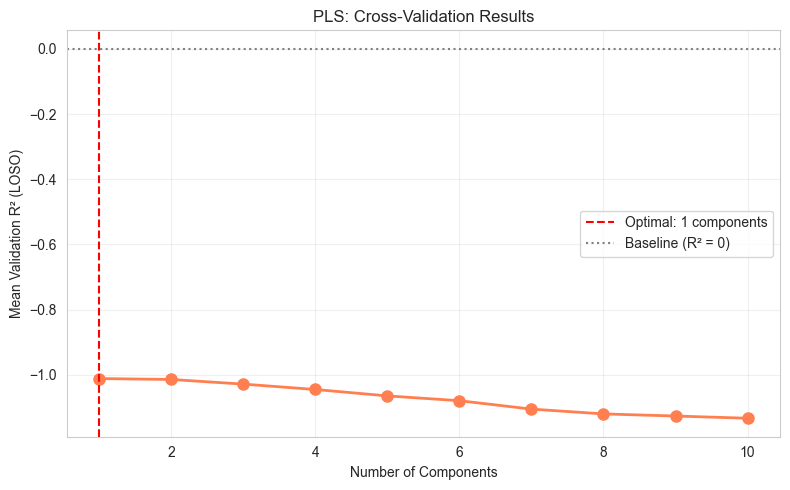

In [8]:
# Cross validation visualization
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pls_cv_scores) + 1), pls_cv_scores, 'o-', color='coral', linewidth=2, markersize=8)
plt.axvline(x=optimal_n_pls, color='red', linestyle='--', label=f'Optimal: {optimal_n_pls} components')
plt.axhline(y=0, color='gray', linestyle=':', label='Baseline (R² = 0)')
plt.xlabel('Number of Components')
plt.ylabel('Mean Validation R² (LOSO)')
plt.title('PLS: Cross-Validation Results')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

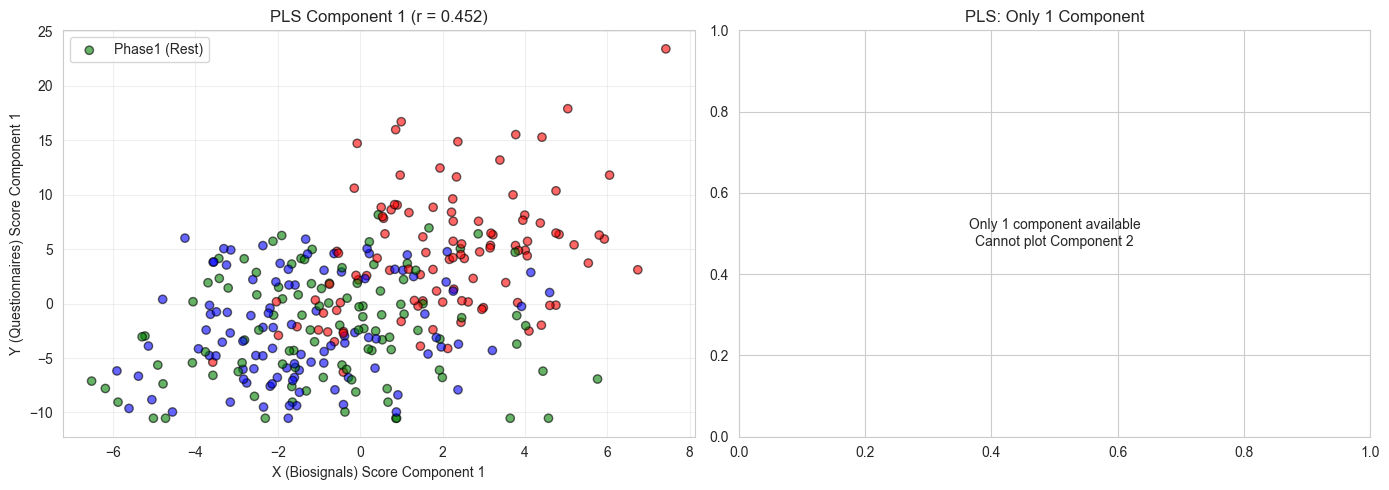

In [9]:
# PLS component visualization
phase_colors = {'phase1': 'blue', 'phase2': 'red', 'phase3': 'green'}
colors = [phase_colors[p] for p in phase_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: X vs Y scores (how well they align)
axes[0].scatter(X_scores[:, 0], Y_scores[:, 0], c=colors, alpha=0.6, edgecolors='k')
axes[0].set_xlabel('X (Biosignals) Score Component 1')
axes[0].set_ylabel('Y (Questionnaires) Score Component 1')
axes[0].set_title(f'PLS Component 1 (r = {correlations_pls[0]:.3f})')
axes[0].legend(['Phase1 (Rest)', 'Phase2 (Puzzle)', 'Phase3 (Recovery)'])
axes[0].grid(True, alpha=0.3)

# Plot 2: X scores colored by Phase (only if 2+ components exist)
if optimal_n_pls >= 2:
    axes[1].scatter(X_scores[:, 0], X_scores[:, 1], c=colors, alpha=0.6, edgecolors='k')
    axes[1].set_xlabel('X Score Component 1')
    axes[1].set_ylabel('X Score Component 2')
    axes[1].set_title('PLS: Biosignals Projection')
    axes[1].legend(['Phase1 (Rest)', 'Phase2 (Puzzle)', 'Phase3 (Recovery)'])
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, f'Only {optimal_n_pls} component available\nCannot plot Component 2', 
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('PLS: Only 1 Component')

plt.tight_layout()
plt.show()

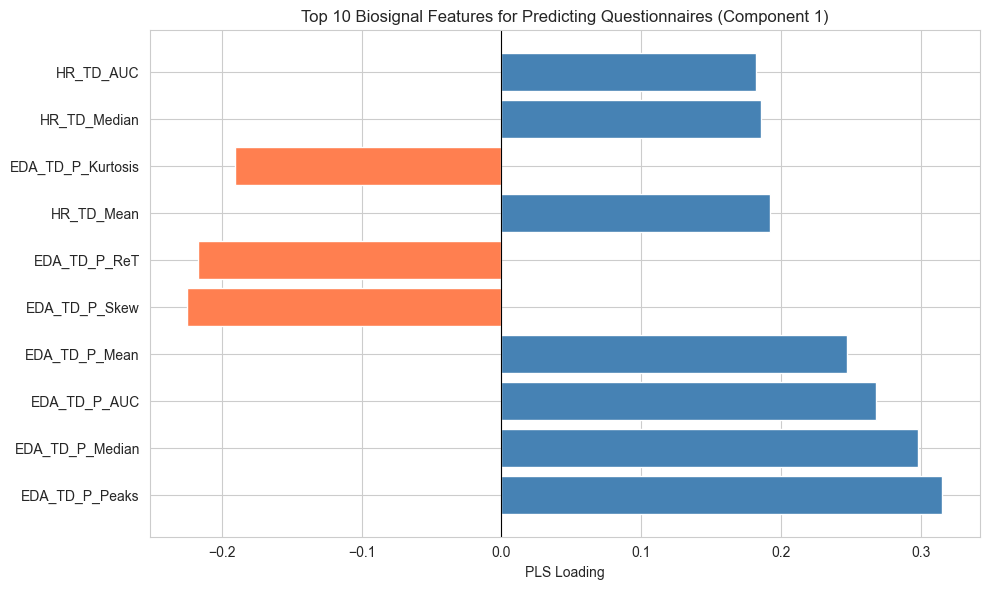


Top 5 Biosignal Features for Component 1:
  1. EDA_TD_P_Peaks: +0.315
  2. EDA_TD_P_Median: +0.298
  3. EDA_TD_P_AUC: +0.268
  4. EDA_TD_P_Mean: +0.247
  5. EDA_TD_P_Skew: -0.225


In [10]:
# Feature loadings 
pls_loadings = pd.DataFrame(
    pls_model.x_rotations_,
    index=biosignal_cols,
    columns=[f'Component_{i+1}' for i in range(pls_model.x_rotations_.shape[1])]
)

# Top 10 features for Component 1
top_features = pls_loadings['Component_1'].abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if x > 0 else 'coral' for x in pls_loadings.loc[top_features.index, 'Component_1']]
plt.barh(range(len(top_features)), pls_loadings.loc[top_features.index, 'Component_1'], color=colors)
plt.yticks(range(len(top_features)), top_features.index)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('PLS Loading')
plt.title('Top 10 Biosignal Features for Predicting Questionnaires (Component 1)')
plt.tight_layout()
plt.show()

print("\nTop 5 Biosignal Features for Component 1:")
for i, (feature, loading) in enumerate(top_features.head(5).items()):
    sign = '+' if pls_loadings.loc[feature, 'Component_1'] > 0 else '-'
    print(f"  {i+1}. {feature}: {sign}{abs(loading):.3f}")

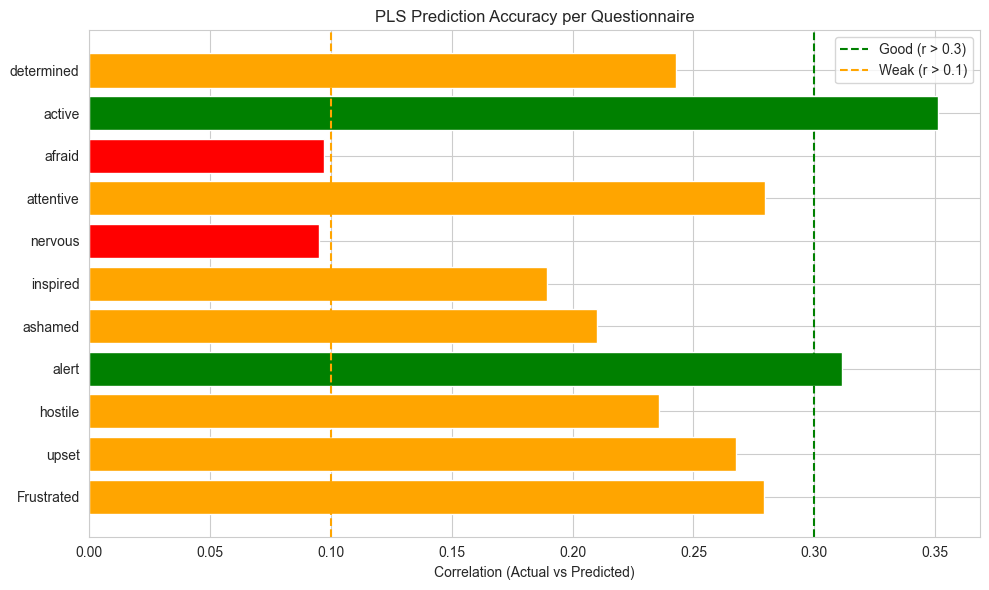


Prediction correlations per questionnaire:
  Frustrated: 0.2791
  upset: 0.2675
  hostile: 0.2359
  alert: 0.3113
  ashamed: 0.2101
  inspired: 0.1894
  nervous: 0.0952
  attentive: 0.2797
  afraid: 0.0969
  active: 0.3511
  determined: 0.2426


In [11]:
# Correlation between actual and predicted for each questionnaire
prediction_corrs = []
for i, col in enumerate(questionnaire_cols):
    corr = np.corrcoef(Y_quest[:, i], y_pred[:, i])[0, 1]
    prediction_corrs.append(corr)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0.3 else 'orange' if c > 0.1 else 'red' for c in prediction_corrs]
plt.barh(questionnaire_cols, prediction_corrs, color=colors)
plt.axvline(x=0.3, color='green', linestyle='--', label='Good (r > 0.3)')
plt.axvline(x=0.1, color='orange', linestyle='--', label='Weak (r > 0.1)')
plt.xlabel('Correlation (Actual vs Predicted)')
plt.title('PLS Prediction Accuracy per Questionnaire')
plt.legend()
plt.tight_layout()
plt.show()

print("\nPrediction correlations per questionnaire:")
for col, corr in zip(questionnaire_cols, prediction_corrs):
    print(f"  {col}: {corr:.4f}")

In [12]:
# Data for CCA (Biosignals vs Emotions)
# Biosignal columns (HR, EDA, TEMP)
biosignal_cols = [c for c in df_clean.columns if c.startswith(('HR_TD_', 'TEMP_TD_', 'EDA_TD_'))]

# Emotion questionnaire columns
emotion_cols = ['Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 
                'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']

# Extract matrices
X_biosignals = X_scaled[biosignal_cols].values
Y_emotions = df_clean[emotion_cols].values

# Metadata for grouping
individual_ids = meta['Individual'].values
phase_labels = meta['Phase'].values

print(f"X (biosignals) shape: {X_biosignals.shape}")
print(f"Y (emotions) shape: {Y_emotions.shape}")

X (biosignals) shape: (307, 51)
Y (emotions) shape: (307, 11)


In [13]:
# CCA cross-validation w/ LOSO 
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.cross_decomposition import CCA

logo = LeaveOneGroupOut()
max_comp = min(X_biosignals.shape[1], Y_emotions.shape[1])

def validate_cca_components_loso(X, Y, groups, max_components):
    "Leave-one-subject-out cross-validation for CCA"
    cv_scores = []
    
    for n_comp in range(1, min(max_components, 11)):
        fold_corrs = []
        
        for train_idx, val_idx in logo.split(X, groups=groups):
            X_train, X_val = X[train_idx], X[val_idx]
            Y_train, Y_val = Y[train_idx], Y[val_idx]
            
            cca = CCA(n_components=n_comp)
            cca.fit(X_train, Y_train)
            X_val_c, Y_val_c = cca.transform(X_val, Y_val)
            
            corrs = [np.corrcoef(X_val_c[:, i], Y_val_c[:, i])[0, 1] 
                     for i in range(n_comp)]
            fold_corrs.append(np.mean(corrs))
        
        cv_scores.append(np.mean(fold_corrs))
    
    return cv_scores

# Run CV
cca_cv_scores = validate_cca_components_loso(X_biosignals, Y_emotions, individual_ids, max_comp)
optimal_n_cca = np.argmax(cca_cv_scores) + 1

print("CCA LOSO Cross-Validation Results (Biosignals vs Emotions):")
for i, score in enumerate(cca_cv_scores[:10]):
    print(f"  {i+1} component(s): mean validation correlation = {score:.4f}")
print(f"\nOptimal number of components: {optimal_n_cca}")
print(f"  (Highest validation correlation: {cca_cv_scores[optimal_n_cca-1]:.4f})")

CCA LOSO Cross-Validation Results (Biosignals vs Emotions):
  1 component(s): mean validation correlation = 0.4454
  2 component(s): mean validation correlation = 0.1485
  3 component(s): mean validation correlation = 0.1576
  4 component(s): mean validation correlation = 0.0962
  5 component(s): mean validation correlation = 0.0558
  6 component(s): mean validation correlation = 0.0249
  7 component(s): mean validation correlation = 0.0178
  8 component(s): mean validation correlation = 0.0427
  9 component(s): mean validation correlation = 0.0399
  10 component(s): mean validation correlation = 0.0673

Optimal number of components: 1
  (Highest validation correlation: 0.4454)


In [14]:
# Fit final CCA with optimal components
cca_model = CCA(n_components=optimal_n_cca)
cca_model.fit(X_biosignals, Y_emotions)

# Transform to get canonical variates
X_c, Y_c = cca_model.transform(X_biosignals, Y_emotions)

# Calculate canonical correlations
cca_correlations = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] 
                    for i in range(optimal_n_cca)]

print(f"Optimal components: {optimal_n_cca}")
for i, corr in enumerate(cca_correlations):
    print(f"  Component {i+1}: {corr:.4f}")

Optimal components: 1
  Component 1: 0.6240


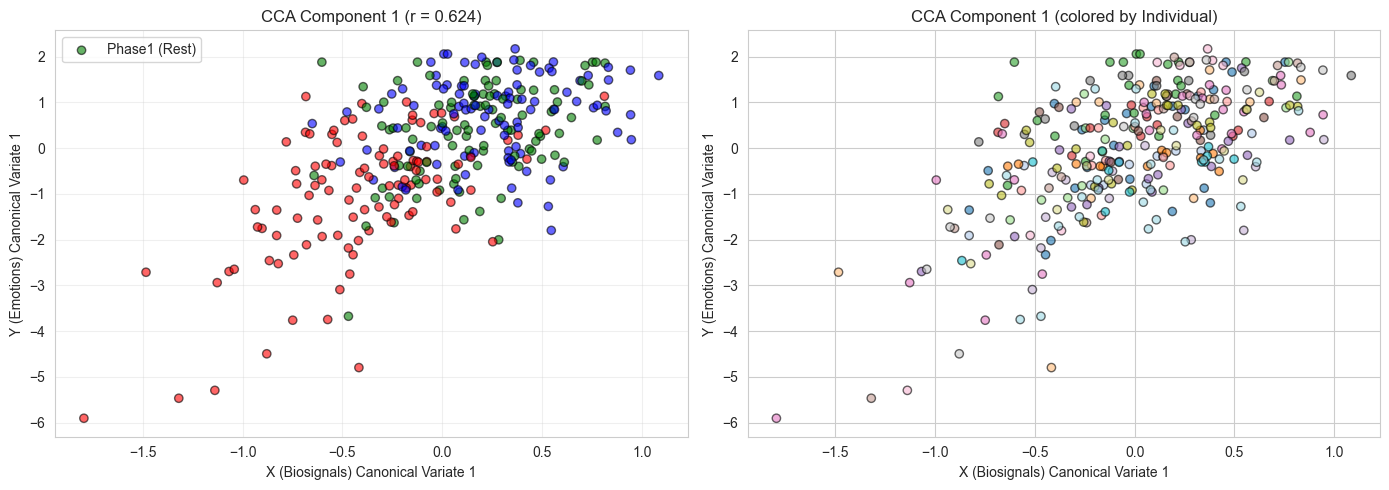

In [15]:
# CCA Visualization
phase_colors = {'phase1': 'blue', 'phase2': 'red', 'phase3': 'green'}
colors = [phase_colors[p] for p in phase_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: X vs Y scores (how well they align)
axes[0].scatter(X_c[:, 0], Y_c[:, 0], c=colors, alpha=0.6, edgecolors='k')
axes[0].set_xlabel('X (Biosignals) Canonical Variate 1')
axes[0].set_ylabel('Y (Emotions) Canonical Variate 1')
axes[0].set_title(f'CCA Component 1 (r = {cca_correlations[0]:.3f})')
axes[0].legend(['Phase1 (Rest)', 'Phase2 (Puzzle)', 'Phase3 (Recovery)'])
axes[0].grid(True, alpha=0.3)

# Plot 2: X scores colored by Individual
unique_indiv = np.unique(individual_ids)
indiv_colors = {ind: i for i, ind in enumerate(unique_indiv)}
indiv_color_nums = [indiv_colors[ind] for ind in individual_ids]

scatter = axes[1].scatter(X_c[:, 0], Y_c[:, 0], c=indiv_color_nums, cmap='tab20', alpha=0.6, edgecolors='k')
axes[1].set_xlabel('X (Biosignals) Canonical Variate 1')
axes[1].set_ylabel('Y (Emotions) Canonical Variate 1')
axes[1].set_title('CCA Component 1 (colored by Individual)')

plt.tight_layout()
plt.show()

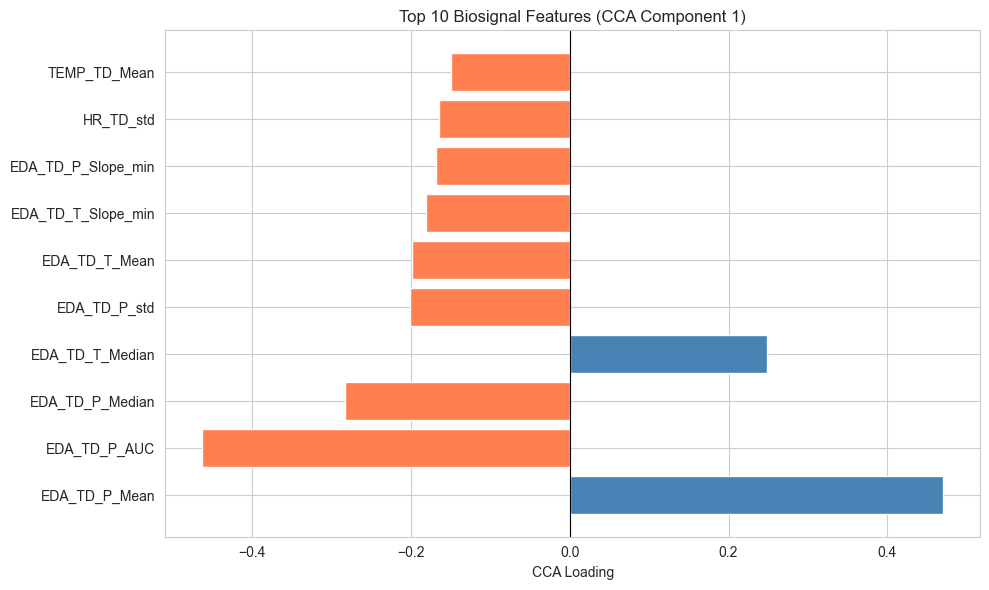


Top 5 Biosignal Features for Component 1:
  1. EDA_TD_P_Mean: +0.470
  2. EDA_TD_P_AUC: -0.462
  3. EDA_TD_P_Median: -0.283
  4. EDA_TD_T_Median: +0.248
  5. EDA_TD_P_std: -0.201


In [16]:
# CCA Feature Loadings
biosignal_loadings = pd.DataFrame(
    cca_model.x_rotations_,
    index=biosignal_cols,
    columns=[f'Component_{i+1}' for i in range(cca_model.x_rotations_.shape[1])]
)

# Top 10 features for Component 1
top_features = biosignal_loadings['Component_1'].abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if x > 0 else 'coral' for x in biosignal_loadings.loc[top_features.index, 'Component_1']]
plt.barh(range(len(top_features)), biosignal_loadings.loc[top_features.index, 'Component_1'], color=colors)
plt.yticks(range(len(top_features)), top_features.index)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('CCA Loading')
plt.title('Top 10 Biosignal Features (CCA Component 1)')
plt.tight_layout()
plt.show()

print("\nTop 5 Biosignal Features for Component 1:")
for i, (feature, loading) in enumerate(top_features.head(5).items()):
    sign = '+' if biosignal_loadings.loc[feature, 'Component_1'] > 0 else '-'
    print(f"  {i+1}. {feature}: {sign}{abs(loading):.3f}")

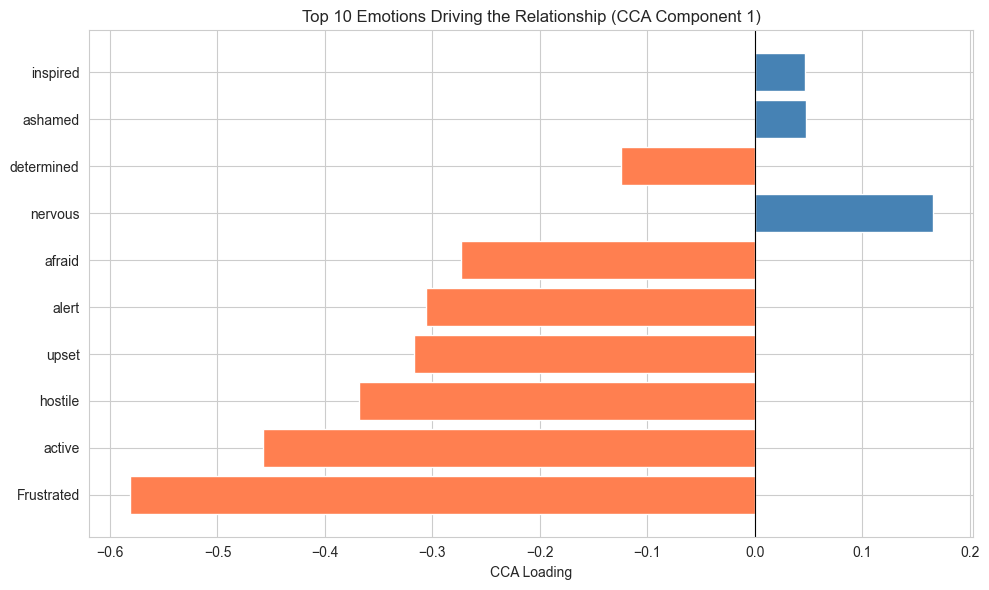


Top 5 Emotions for Component 1:
  1. Frustrated: -0.582
  2. active: -0.457
  3. hostile: -0.369
  4. upset: -0.317
  5. alert: -0.306


In [17]:
emotion_loadings = pd.DataFrame(
    cca_model.y_rotations_,
    index=emotion_cols,
    columns=[f'Component_{i+1}' for i in range(cca_model.y_rotations_.shape[1])]
)

# Top emotions for Component 1
top_emotions = emotion_loadings['Component_1'].abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if x > 0 else 'coral' for x in emotion_loadings.loc[top_emotions.index, 'Component_1']]
plt.barh(range(len(top_emotions)), emotion_loadings.loc[top_emotions.index, 'Component_1'], color=colors)
plt.yticks(range(len(top_emotions)), top_emotions.index)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('CCA Loading')
plt.title('Top 10 Emotions Driving the Relationship (CCA Component 1)')
plt.tight_layout()
plt.show()

print("\nTop 5 Emotions for Component 1:")
for i, (emotion, loading) in enumerate(top_emotions.head(5).items()):
    sign = '+' if emotion_loadings.loc[emotion, 'Component_1'] > 0 else '-'
    print(f"  {i+1}. {emotion}: {sign}{abs(loading):.3f}")

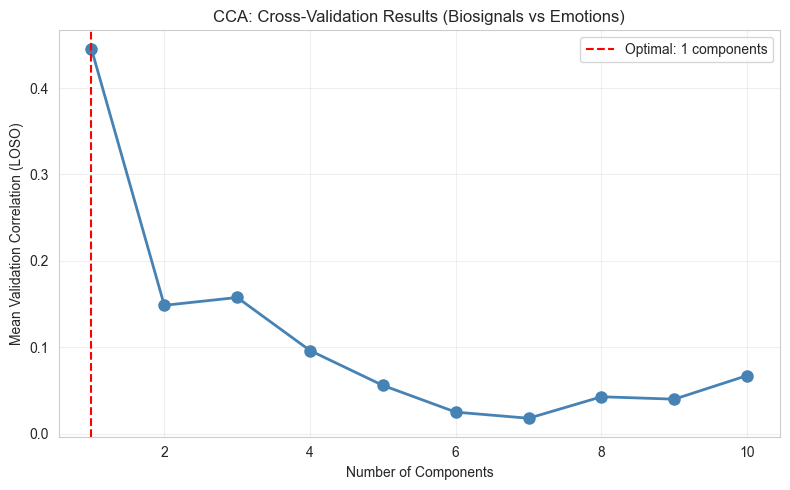

In [18]:
# Cross validation visualization
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cca_cv_scores) + 1), cca_cv_scores, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.axvline(x=optimal_n_cca, color='red', linestyle='--', label=f'Optimal: {optimal_n_cca} components')
plt.xlabel('Number of Components')
plt.ylabel('Mean Validation Correlation (LOSO)')
plt.title('CCA: Cross-Validation Results (Biosignals vs Emotions)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()